In [4]:
import pandas as pd
df = pd.read_csv('tips.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   gender      244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


In [8]:
df.head()

,total_bill,tip,gender,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [9]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [7]:
df['day'].value_counts(normalize=True)

day
Sat     0.356557
Sun     0.311475
Thur    0.254098
Fri     0.077869
Name: proportion, dtype: float64

<BarContainer object of 4 artists>

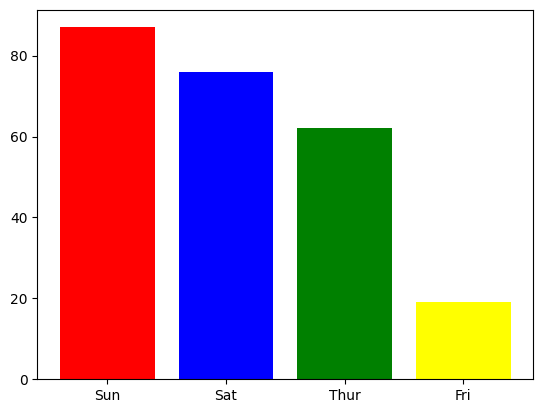

In [17]:
import matplotlib.pyplot as plt
plt.bar(x=df['day'].unique(), height=df['day'].value_counts(),color=['red','blue','green','yellow'])

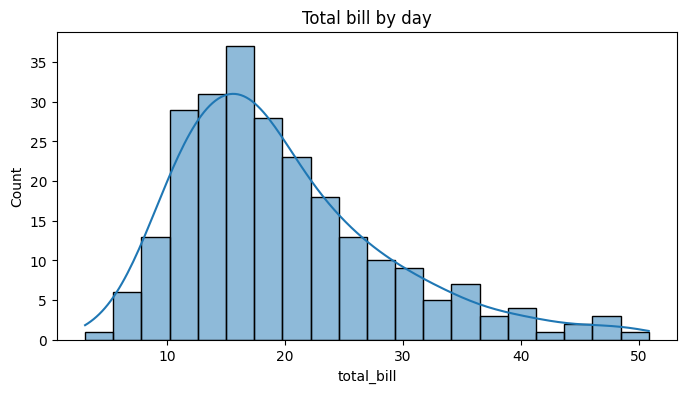

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.histplot(df["total_bill"],kde=True,bins=20)
plt.title("Total bill by day")
plt.show()

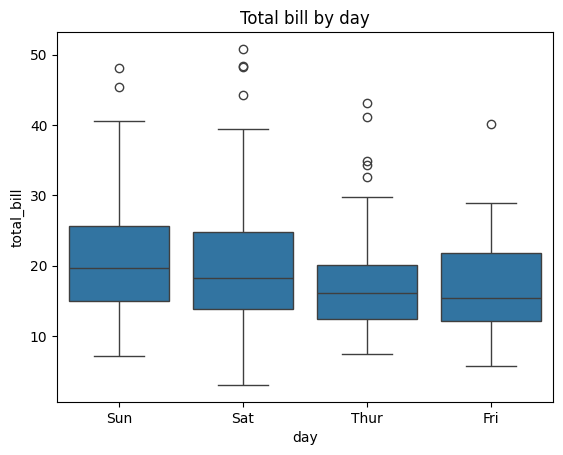

In [22]:
sns.boxplot(x='day',y='total_bill',data=df)
plt.title("Total bill by day")
plt.show()

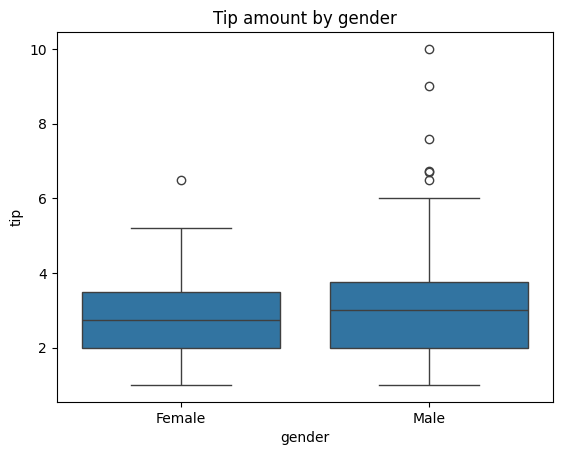

In [25]:
sns.boxplot(x='gender',y='tip',data=df)
plt.title("Tip amount by gender")
plt.show()

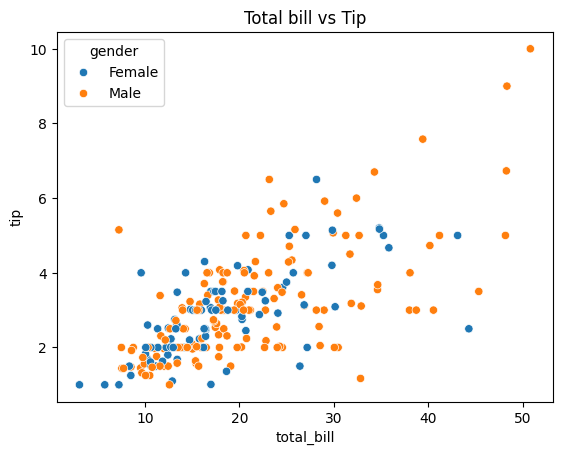

In [26]:
sns.scatterplot(x='total_bill',y='tip',hue='gender',data=df)
plt.title("Total bill vs Tip")
plt.show()

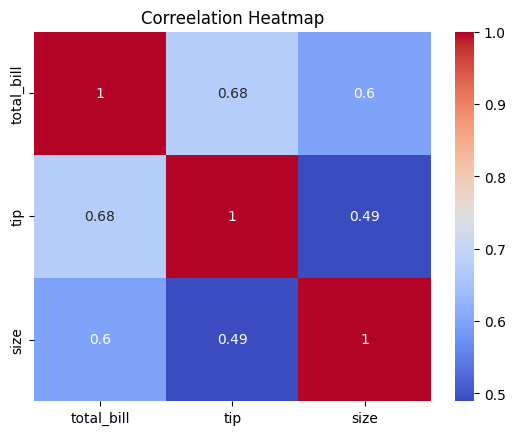

In [29]:
#correlation matrix
corr_mat = df.select_dtypes(include="number").corr()
sns.heatmap(corr_mat,annot=True,cmap='coolwarm')
plt.title("Correelation Heatmap")
plt.show()

In [ ]:
from scipy import stats
contingency_table = pd.crosstab(df['gender'],df['smoker'])
print(contingency_table)
chi2,p,dof,expected = stats.chi2_contingency(contingency_table,correction=False)
print(f'chi2 = {chi2},p-value = {p},dof = {dof},expexted = {expected}')

smoker  No  Yes
gender         
Female  54   33
Male    97   60
chi2 = 0.001934818536627623,p = 0.964915107315732,dof = 1,expexted = [[53.84016393 33.15983607]
 [97.15983607 59.84016393]]


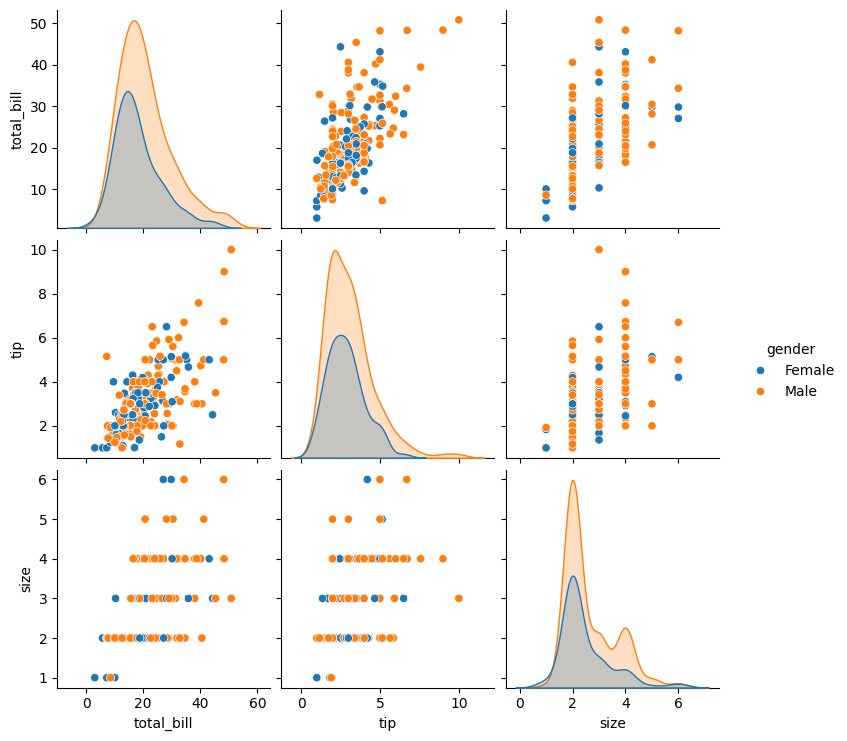

In [37]:
sns.pairplot(df,hue='gender')
plt.show()

In [ ]:
from ydata_profiling import ProfileReport